# Food Insecurity Modelling

**Project:** Drivers of Food Insecurity in London, United Kingdom

Workflow:

1. Load final coded food-security dataset
2. Construct the four-class ordinal target
3. Remove identifiers and leakage-prone fields
4. Create reproducible train/validation/test splits
5. Define feature groups and model-specific preprocessing
6. Train four baseline models
7. Evaluate baseline models
8. Train targeted improved models using class weighting and regularisation
9. Export complete improved validation diagnostics
10. Select the stronger baseline/improved configuration per algorithm using validation Macro F1
11. Evaluate frozen configurations once on the untouched test set
12. Run SHAP explainability
13. Save deployment artifacts and metadata

**Important:** The test set is not used for model selection or tuning.


## 1. Imports and configuration


In [1]:
from pathlib import Path
import json
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    cohen_kappa_score, roc_auc_score, average_precision_score,
    precision_recall_fscore_support
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("../data/finalised_dataset/food_security_fully_coded_v2.csv")
OUTPUT_ROOT = Path("../outputs/Training/food_insecurity")
BASELINE_DIR = OUTPUT_ROOT / "baseline_ml"
IMPROVED_DIR = OUTPUT_ROOT / "improved_ml"
TEST_DIR = OUTPUT_ROOT / "test"
FIGURE_DIR = OUTPUT_ROOT / "figures"
MODEL_DIR = Path("../models/food_security")

for directory in [BASELINE_DIR, IMPROVED_DIR, TEST_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


## 2. Load data and construct target


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

def create_food_security_class(score):
    if score <= 1:
        return 0
    elif score <= 3:
        return 1
    elif score <= 6:
        return 2
    return 3

CLASS_LABELS = {
    0: "High",
    1: "Marginal",
    2: "Low",
    3: "Very Low"
}
CLASS_ORDER = [0, 1, 2, 3]
CLASS_NAMES = [CLASS_LABELS[i] for i in CLASS_ORDER]

df["target"] = df["food_security_score"].apply(create_food_security_class)

target_summary = pd.DataFrame({
    "Count": df["target"].value_counts().sort_index(),
    "Percentage": df["target"].value_counts(normalize=True).sort_index().mul(100).round(2)
})
target_summary.index = [CLASS_LABELS[i] for i in target_summary.index]
display(target_summary)


Dataset shape: (2886, 17)


,participant_id,Gender_Code,Work_Schedule_Code,Age_range_Code,Household_type_code,Life_satisfaction,Isolation_score,Social_support_score,food_security_score,Housing_tenure_group_code,Income_Code,Lad_code_code,msoa_code_code,imd_decile,green_space_pct,park_distance_m,crime_rate_per_1000
0,01g1puj0zbtyyl68d9l01g1pujrxajj5,1,2,3,1,4,0,2,9,1,4,9000013,2000387,7,66.5,411.026450,113.597404
1,01h0q6h87uvwo01h0qeji2vxnl4z78ik,1,2,6,1,6,1,1,0,2,4,9000015,2006882,7,95.2,722.929373,61.229398
2,01nhwhotteqvsg5qfl301nhwho84uknz,2,7,4,2,8,2,2,9,3,0,9000033,2000981,7,89.8,438.816681,372.933205
3,020yzynec712xmojk020yzynd1hjo9pl,1,2,9,2,9,0,2,0,1,3,9000009,2000276,5,90.2,360.395918,81.460788
4,029tb4078h9gvgwasyk029tb49nw0foj,2,2,9,3,7,2,2,0,2,3,9000029,2000852,10,94.3,454.377365,64.105795


,Count,Percentage
High,1706,59.11
Marginal,307,10.64
Low,349,12.09
Very Low,524,18.16


## 3. Predictor definition and leakage controls


In [3]:
y = df["target"].copy()

DROP_COLUMNS = [
    "participant_id",
    "food_security_score",
    "Lad_code_code",
    "msoa_code_code"
]

X = df.drop(columns=DROP_COLUMNS + ["target"]).copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("Predictors:")
print(X.columns.tolist())

# Opposite deprivation target must not be available to this model.
assert "fuel-security_score" not in X.columns, (
    "Leakage risk: fuel-security-score is still present in the food model predictors."
)


Predictor shape: (2886, 13)
Target shape: (2886,)
Predictors:
['Gender_Code', 'Work_Schedule_Code', 'Age_range_Code', 'Household_type_code', 'Life_satisfaction', 'Isolation_score', 'Social_support_score', 'Housing_tenure_group_code', 'Income_Code', 'imd_decile', 'green_space_pct', 'park_distance_m', 'crime_rate_per_1000']


## 4. Reproducible train / validation / test split


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_val) + len(X_test) == len(X)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

def split_distribution(y_split):
    return pd.DataFrame({
        "Count": y_split.value_counts().reindex(CLASS_ORDER, fill_value=0),
        "Percentage": y_split.value_counts(normalize=True).reindex(CLASS_ORDER, fill_value=0).mul(100).round(2)
    })

print("\nTrain distribution")
display(split_distribution(y_train))
print("Validation distribution")
display(split_distribution(y_val))
print("Test distribution")
display(split_distribution(y_test))


Train: (2020, 13)
Validation: (433, 13)
Test: (433, 13)

Train distribution


,Count,Percentage
target,,
0,1194,59.11
1,215,10.64
2,244,12.08
3,367,18.17


Validation distribution


,Count,Percentage
target,,
0,256,59.12
1,46,10.62
2,52,12.01
3,79,18.24


Test distribution


,Count,Percentage
target,,
0,256,59.12
1,46,10.62
2,53,12.24
3,78,18.01


## 5. Feature groups


In [5]:
nominal_features = [
    "Gender_Code",
    "Work_Schedule_Code",
    "Household_type_code",
    "Housing_tenure_group_code"
]

ordinal_features = [
    "Age_range_Code",
    "Income_Code",
    "imd_decile"
]

continuous_features = [
    "Life_satisfaction",
    "Isolation_score",
    "Social_support_score",
    "green_space_pct",
    "park_distance_m",
    "crime_rate_per_1000"
]

all_defined_features = nominal_features + ordinal_features + continuous_features

assert len(all_defined_features) == len(set(all_defined_features))
assert set(all_defined_features) == set(X.columns), (
    f"Feature definition mismatch. Missing from definitions: {set(X.columns)-set(all_defined_features)}; "
    f"Unexpected definitions: {set(all_defined_features)-set(X.columns)}"
)

display(pd.DataFrame({
    "dtype": X_train.dtypes,
    "missing_count": X_train.isna().sum(),
    "missing_pct": X_train.isna().mean().mul(100).round(2),
    "unique_values": X_train.nunique()
}))


,dtype,missing_count,missing_pct,unique_values
Gender_Code,int64,0,0.0,4
Work_Schedule_Code,int64,0,0.0,13
Age_range_Code,int64,0,0.0,14
Household_type_code,int64,0,0.0,6
Life_satisfaction,int64,0,0.0,10
Isolation_score,int64,0,0.0,3
Social_support_score,int64,0,0.0,3
Housing_tenure_group_code,int64,0,0.0,9
Income_Code,int64,0,0.0,6
imd_decile,int64,0,0.0,10


## 6. Reusable evaluation functions


In [6]:
def evaluate_model(y_true, y_pred, y_proba=None):
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Quadratic Weighted Kappa": cohen_kappa_score(y_true, y_pred, weights="quadratic")
    }

    if y_proba is not None:
        result["ROC AUC OVR Macro"] = roc_auc_score(
            y_true, y_proba, multi_class="ovr", average="macro"
        )
        y_bin = label_binarize(y_true, classes=CLASS_ORDER)
        result["PR AUC Macro"] = average_precision_score(
            y_bin, y_proba, average="macro"
        )

    return pd.Series(result)


def per_class_metrics(y_true, y_pred, model_name):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, zero_division=0
    )

    return pd.DataFrame({
        "Model": model_name,
        "Class": CLASS_NAMES,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Support": support
    })


def ordinal_error_summary(y_true, y_pred):
    true_arr = np.asarray(y_true)
    pred_arr = np.asarray(y_pred)
    distance = np.abs(true_arr - pred_arr)

    return pd.Series({
        "Mean Class Distance": distance.mean(),
        "Exact Classification %": (distance == 0).mean() * 100,
        "Off By One Class %": (distance == 1).mean() * 100,
        "Off By Two+ Classes %": (distance >= 2).mean() * 100
    })


def evaluate_model_collection(model_inputs, y_true):
    metrics = {}
    predictions = {}
    probabilities = {}

    for name, (model, X_eval) in model_inputs.items():
        pred = np.asarray(model.predict(X_eval)).ravel()
        proba = model.predict_proba(X_eval)

        predictions[name] = pred
        probabilities[name] = proba
        metrics[name] = evaluate_model(y_true, pred, proba)

    metrics_df = pd.DataFrame(metrics).T.sort_values("Macro F1", ascending=False)

    per_class_df = pd.concat(
        [per_class_metrics(y_true, pred, name) for name, pred in predictions.items()],
        ignore_index=True
    )

    ordinal_df = pd.DataFrame({
        name: ordinal_error_summary(y_true, pred)
        for name, pred in predictions.items()
    }).T

    return metrics_df, per_class_df, ordinal_df, predictions, probabilities


def save_confusion_matrices(predictions, y_true, output_dir, prefix):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for model_name, pred in predictions.items():
        cm = confusion_matrix(y_true, pred, labels=CLASS_ORDER)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        )
        disp.plot(values_format="d")
        plt.title(f"{model_name} - {prefix}")
        plt.tight_layout()

        filename = model_name.lower().replace(" ", "_")
        plt.savefig(
            output_dir / f"{filename}_{prefix.lower().replace(' ', '_')}_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()


def generalisation_table(train_inputs, val_inputs, y_train, y_val):
    rows = []

    for name in train_inputs:
        train_model, Xtr = train_inputs[name]
        val_model, Xv = val_inputs[name]

        train_pred = np.asarray(train_model.predict(Xtr)).ravel()
        val_pred = np.asarray(val_model.predict(Xv)).ravel()

        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)
        train_f1 = f1_score(y_train, train_pred, average="macro", zero_division=0)
        val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)

        rows.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Validation Accuracy": val_acc,
            "Accuracy Gap": train_acc - val_acc,
            "Train Macro F1": train_f1,
            "Validation Macro F1": val_f1,
            "Macro F1 Gap": train_f1 - val_f1
        })

    return pd.DataFrame(rows).sort_values("Validation Macro F1", ascending=False)


## 7. Model-specific preprocessing


In [7]:
# Logistic Regression: one-hot nominal features; scale ordinal and continuous features.
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

scaled_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

logistic_preprocessor = ColumnTransformer([
    ("nominal", nominal_pipeline, nominal_features),
    ("ordinal", scaled_numeric_pipeline, ordinal_features),
    ("continuous", scaled_numeric_pipeline, continuous_features)
])

# Tree models: one-hot nominal features; no scaling for numeric features.
rf_nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

rf_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

tree_preprocessor = ColumnTransformer([
    ("nominal", rf_nominal_pipeline, nominal_features),
    ("ordinal", rf_numeric_pipeline, ordinal_features),
    ("continuous", rf_numeric_pipeline, continuous_features)
])

# CatBoost: retain nominal variables as categorical strings.
def prepare_catboost_frame(frame):
    frame = frame.copy()
    for col in nominal_features:
        frame[col] = frame[col].fillna(-1).astype(str)
    return frame

X_train_cat = prepare_catboost_frame(X_train)
X_val_cat = prepare_catboost_frame(X_val)


## 8. Baseline models


In [8]:
baseline_lr = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

baseline_rf = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

baseline_xgb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        eval_metric="mlogloss"
    ))
])

baseline_cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

baseline_lr.fit(X_train, y_train)
baseline_rf.fit(X_train, y_train)
baseline_xgb.fit(X_train, y_train)
baseline_cat.fit(X_train_cat, y_train, cat_features=nominal_features)


CatBoostClassifier(allow_writing_files=False, depth=6, iterations=300, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=False)

## 9. Baseline validation evaluation


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,Quadratic Weighted Kappa,ROC AUC OVR Macro,PR AUC Macro
XGBoost,0.6559,0.4456,0.4077,0.4016,0.6028,0.4077,0.4930,0.7521,0.4578
CatBoost,0.6674,0.4583,0.4026,0.3791,0.5933,0.4026,0.4931,0.7683,0.4773
Random Forest,0.6605,0.4219,0.3855,0.3659,0.5870,0.3855,0.4889,0.7397,0.4450
Logistic Regression,0.6582,0.3541,0.3828,0.3520,0.5769,0.3828,0.4767,0.7517,0.4556


,Model,Train Accuracy,Validation Accuracy,Accuracy Gap,Train Macro F1,Validation Macro F1,Macro F1 Gap
2,XGBoost,0.9693,0.6559,0.3134,0.9615,0.4016,0.5599
3,CatBoost,0.7282,0.6674,0.0608,0.5066,0.3791,0.1275
1,Random Forest,1.0000,0.6605,0.3395,1.0000,0.3659,0.6341
0,Logistic Regression,0.6614,0.6582,0.0032,0.3702,0.3520,0.0182


,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,High,0.6839,0.9297,0.7881,256
1,Logistic Regression,Marginal,0.0000,0.0000,0.0000,46
2,Logistic Regression,Low,0.1429,0.0192,0.0339,52
3,Logistic Regression,Very Low,0.5897,0.5823,0.5860,79
4,Random Forest,High,0.6977,0.9375,0.8000,256
5,Random Forest,Marginal,0.1667,0.0217,0.0385,46
6,Random Forest,Low,0.2500,0.0385,0.0667,52
7,Random Forest,Very Low,0.5733,0.5443,0.5584,79
8,XGBoost,High,0.7130,0.9023,0.7966,256
9,XGBoost,Marginal,0.1667,0.0435,0.0690,46


,Mean Class Distance,Exact Classification %,Off By One Class %,Off By Two+ Classes %
Logistic Regression,0.6628,65.8199,12.4711,21.7090
Random Forest,0.6467,66.0508,13.1640,20.7852
XGBoost,0.6559,65.5889,12.4711,21.9400
CatBoost,0.6490,66.7436,12.2402,21.0162


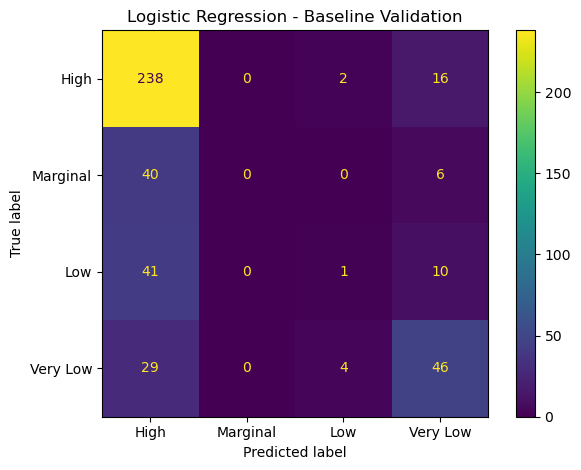

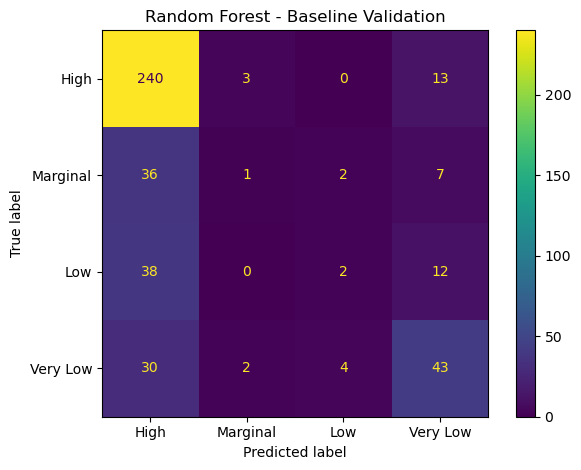

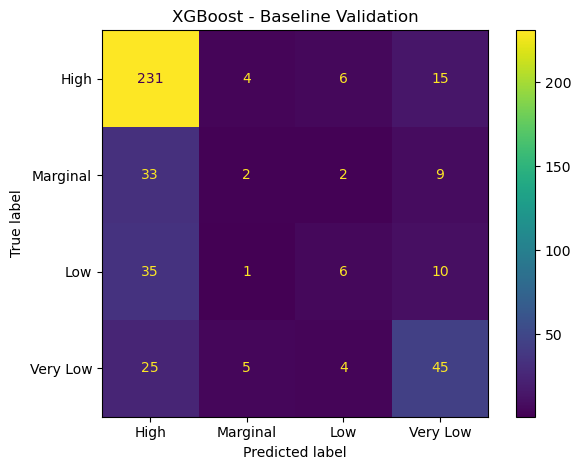

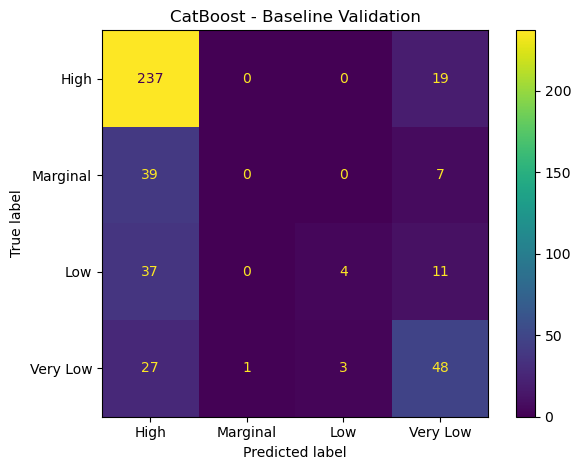

In [9]:
baseline_val_inputs = {
    "Logistic Regression": (baseline_lr, X_val),
    "Random Forest": (baseline_rf, X_val),
    "XGBoost": (baseline_xgb, X_val),
    "CatBoost": (baseline_cat, X_val_cat)
}

baseline_train_inputs = {
    "Logistic Regression": (baseline_lr, X_train),
    "Random Forest": (baseline_rf, X_train),
    "XGBoost": (baseline_xgb, X_train),
    "CatBoost": (baseline_cat, X_train_cat)
}

(
    baseline_validation_results,
    baseline_per_class,
    baseline_ordinal,
    baseline_predictions,
    baseline_probabilities
) = evaluate_model_collection(baseline_val_inputs, y_val)

baseline_generalisation = generalisation_table(
    baseline_train_inputs, baseline_val_inputs, y_train, y_val
)

display(baseline_validation_results.round(4))
display(baseline_generalisation.round(4))
display(baseline_per_class.round(4))
display(baseline_ordinal.round(4))

baseline_validation_results.to_csv(BASELINE_DIR / "baseline_validation_metrics.csv")
baseline_generalisation.to_csv(BASELINE_DIR / "baseline_generalisation.csv", index=False)
baseline_per_class.to_csv(BASELINE_DIR / "baseline_per_class_metrics.csv", index=False)
baseline_ordinal.to_csv(BASELINE_DIR / "baseline_ordinal_error_analysis.csv")

save_confusion_matrices(
    baseline_predictions, y_val, FIGURE_DIR / "baseline", "Baseline Validation"
)


## 10. Targeted model improvement

The baseline analysis showed strong majority-class performance but weak recognition of the Marginal and Low classes. The improved models therefore use class weighting. Random Forest and XGBoost also receive additional regularisation because their baseline train/validation gaps indicated overfitting.

These are targeted improvements, not an exhaustive hyperparameter search.


In [10]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))
sample_weights = y_train.map(class_weights)

print("Training-derived class weights:", class_weights)

lr_improved = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        C=0.5,
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

rf_improved = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

xgb_improved = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=2.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        eval_metric="mlogloss"
    ))
])

cat_improved = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=5,
    loss_function="MultiClass",
    class_weights=class_weights,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

lr_improved.fit(X_train, y_train)
rf_improved.fit(X_train, y_train)
xgb_improved.fit(
    X_train, y_train,
    classifier__sample_weight=sample_weights
)
cat_improved.fit(
    X_train_cat, y_train,
    cat_features=nominal_features
)


Training-derived class weights: {0: 0.42294807370184256, 1: 2.3488372093023258, 2: 2.069672131147541, 3: 1.3760217983651226}


CatBoostClassifier(allow_writing_files=False, class_weights={0: 0.42294807370184256, 1: 2.3488372093023258, 2: 2.069672131147541, 3: 1.3760217983651226}, depth=5, iterations=500, learning_rate=0.03, loss_function='MultiClass', random_seed=42, verbose=False)

## 11. Improved validation evaluation and exports


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,Quadratic Weighted Kappa,ROC AUC OVR Macro,PR AUC Macro
XGBoost,0.6259,0.4561,0.4778,0.4633,0.6365,0.4778,0.6004,0.7601,0.4595
Random Forest,0.6351,0.4603,0.4748,0.4631,0.6325,0.4748,0.5600,0.7724,0.4690
CatBoost,0.6028,0.4565,0.4700,0.4595,0.6215,0.4700,0.5850,0.7755,0.4807
Logistic Regression,0.5866,0.4570,0.4576,0.4517,0.6106,0.4576,0.5703,0.7461,0.4567


,Model,Train Accuracy,Validation Accuracy,Accuracy Gap,Train Macro F1,Validation Macro F1,Macro F1 Gap
2,XGBoost,0.8005,0.6259,0.1746,0.7714,0.4633,0.3081
1,Random Forest,0.7876,0.6351,0.1525,0.7493,0.4631,0.2862
3,CatBoost,0.6906,0.6028,0.0878,0.6196,0.4595,0.1601
0,Logistic Regression,0.5723,0.5866,-0.0143,0.4584,0.4517,0.0067


,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,High,0.8318,0.7148,0.7689,256
1,Logistic Regression,Marginal,0.1566,0.2826,0.2016,46
2,Logistic Regression,Low,0.2885,0.2885,0.2885,52
3,Logistic Regression,Very Low,0.5513,0.5443,0.5478,79
4,Random Forest,High,0.8197,0.7812,0.8000,256
5,Random Forest,Marginal,0.2258,0.1522,0.1818,46
6,Random Forest,Low,0.2909,0.3077,0.2991,52
7,Random Forest,Very Low,0.5049,0.6582,0.5714,79
8,XGBoost,High,0.8622,0.7578,0.8067,256
9,XGBoost,Marginal,0.2115,0.2391,0.2245,46


Class,High,Low,Marginal,Very Low
Model,,,,
CatBoost,0.7344,0.2500,0.3261,0.5696
Logistic Regression,0.7148,0.2885,0.2826,0.5443
Random Forest,0.7812,0.3077,0.1522,0.6582
XGBoost,0.7578,0.2308,0.2391,0.6835


,Mean Class Distance,Exact Classification %,Off By One Class %,Off By Two+ Classes %
Logistic Regression,0.6374,58.6605,24.4804,16.8591
Random Forest,0.6443,63.5104,16.3972,20.0924
XGBoost,0.6143,62.5866,19.6305,17.7829
CatBoost,0.6189,60.2771,23.7875,15.9353


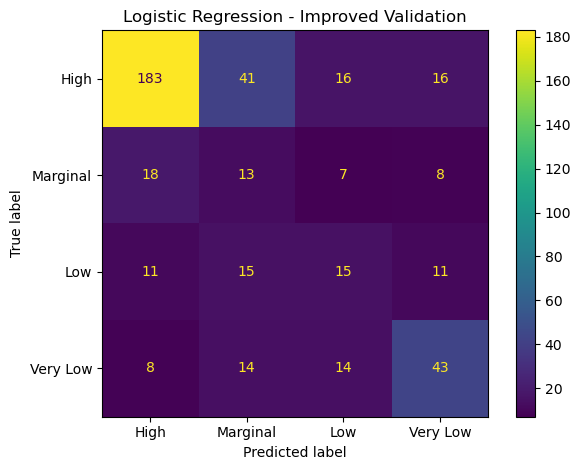

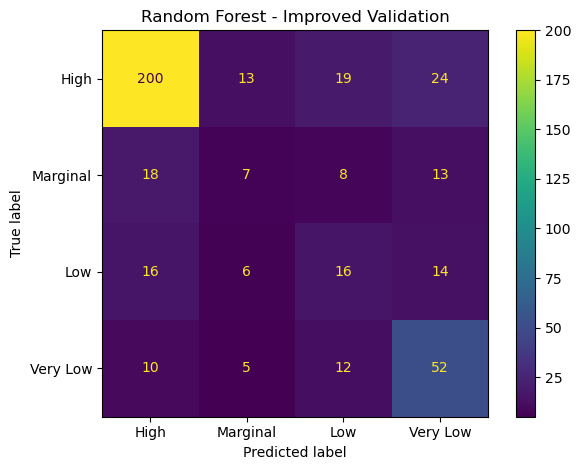

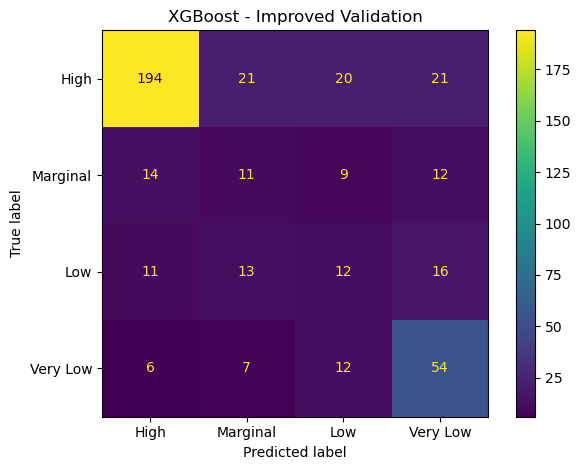

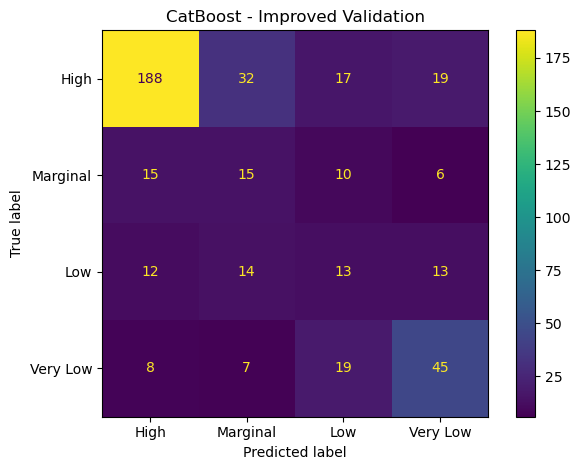

In [11]:
improved_val_inputs = {
    "Logistic Regression": (lr_improved, X_val),
    "Random Forest": (rf_improved, X_val),
    "XGBoost": (xgb_improved, X_val),
    "CatBoost": (cat_improved, X_val_cat)
}

improved_train_inputs = {
    "Logistic Regression": (lr_improved, X_train),
    "Random Forest": (rf_improved, X_train),
    "XGBoost": (xgb_improved, X_train),
    "CatBoost": (cat_improved, X_train_cat)
}

(
    improved_validation_results,
    improved_per_class,
    improved_ordinal,
    improved_predictions,
    improved_probabilities
) = evaluate_model_collection(improved_val_inputs, y_val)

improved_generalisation = generalisation_table(
    improved_train_inputs, improved_val_inputs, y_train, y_val
)

improved_recall = improved_per_class.pivot(
    index="Model", columns="Class", values="Recall"
)

display(improved_validation_results.round(4))
display(improved_generalisation.round(4))
display(improved_per_class.round(4))
display(improved_recall.round(4))
display(improved_ordinal.round(4))

improved_validation_results.to_csv(IMPROVED_DIR / "improved_validation_metrics.csv")
improved_generalisation.to_csv(IMPROVED_DIR / "improved_generalisation.csv", index=False)
improved_per_class.to_csv(IMPROVED_DIR / "improved_per_class_metrics.csv", index=False)
improved_recall.to_csv(IMPROVED_DIR / "improved_class_recall.csv")
improved_ordinal.to_csv(IMPROVED_DIR / "improved_ordinal_error_analysis.csv")

save_confusion_matrices(
    improved_predictions, y_val, FIGURE_DIR / "improved", "Improved Validation"
)


## 12. Baseline versus improved comparison and model freeze


In [12]:
comparison_rows = []

for model_name in baseline_validation_results.index:
    comparison_rows.append({
        "Model": model_name,
        "Baseline Accuracy": baseline_validation_results.loc[model_name, "Accuracy"],
        "Improved Accuracy": improved_validation_results.loc[model_name, "Accuracy"],
        "Baseline Macro F1": baseline_validation_results.loc[model_name, "Macro F1"],
        "Improved Macro F1": improved_validation_results.loc[model_name, "Macro F1"],
        "Baseline Balanced Accuracy": baseline_validation_results.loc[model_name, "Balanced Accuracy"],
        "Improved Balanced Accuracy": improved_validation_results.loc[model_name, "Balanced Accuracy"],
        "Baseline QWK": baseline_validation_results.loc[model_name, "Quadratic Weighted Kappa"],
        "Improved QWK": improved_validation_results.loc[model_name, "Quadratic Weighted Kappa"]
    })

validation_comparison = pd.DataFrame(comparison_rows)
validation_comparison["Macro F1 Change"] = (
    validation_comparison["Improved Macro F1"] -
    validation_comparison["Baseline Macro F1"]
)

display(validation_comparison.round(4))
validation_comparison.to_csv(
    IMPROVED_DIR / "baseline_vs_improved_comparison.csv",
    index=False
)

# Freeze one configuration per algorithm using validation Macro F1.
baseline_models = {
    "Logistic Regression": baseline_lr,
    "Random Forest": baseline_rf,
    "XGBoost": baseline_xgb,
    "CatBoost": baseline_cat
}

improved_models = {
    "Logistic Regression": lr_improved,
    "Random Forest": rf_improved,
    "XGBoost": xgb_improved,
    "CatBoost": cat_improved
}

selected_models = {}
selected_variant = {}

for name in baseline_models:
    baseline_f1 = baseline_validation_results.loc[name, "Macro F1"]
    improved_f1 = improved_validation_results.loc[name, "Macro F1"]

    if improved_f1 >= baseline_f1:
        selected_models[name] = improved_models[name]
        selected_variant[name] = "improved"
    else:
        selected_models[name] = baseline_models[name]
        selected_variant[name] = "baseline"

selection_df = pd.DataFrame({
    "Model": list(selected_variant.keys()),
    "Selected Variant": list(selected_variant.values())
})

display(selection_df)
selection_df.to_csv(IMPROVED_DIR / "selected_model_variants.csv", index=False)

print("MODEL DEVELOPMENT IS NOW FROZEN. Do not tune after viewing test results.")


,Model,Baseline Accuracy,Improved Accuracy,Baseline Macro F1,Improved Macro F1,Baseline Balanced Accuracy,Improved Balanced Accuracy,Baseline QWK,Improved QWK,Macro F1 Change
0,XGBoost,0.6559,0.6259,0.4016,0.4633,0.4077,0.4778,0.4930,0.6004,0.0616
1,CatBoost,0.6674,0.6028,0.3791,0.4595,0.4026,0.4700,0.4931,0.5850,0.0804
2,Random Forest,0.6605,0.6351,0.3659,0.4631,0.3855,0.4748,0.4889,0.5600,0.0972
3,Logistic Regression,0.6582,0.5866,0.3520,0.4517,0.3828,0.4576,0.4767,0.5703,0.0997


,Model,Selected Variant
0,Logistic Regression,improved
1,Random Forest,improved
2,XGBoost,improved
3,CatBoost,improved


MODEL DEVELOPMENT IS NOW FROZEN. Do not tune after viewing test results.


## 13. Final untouched test evaluation

Run this section only after the model configurations above are frozen. Test results are for final generalisation assessment, not further tuning.


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,Quadratic Weighted Kappa,ROC AUC OVR Macro,PR AUC Macro
CatBoost,0.5912,0.4409,0.4538,0.4416,0.6132,0.4538,0.5976,0.7462,0.4424
XGBoost,0.5774,0.4134,0.4256,0.4161,0.5970,0.4256,0.5567,0.7296,0.4290
Random Forest,0.5912,0.3936,0.4122,0.3999,0.5941,0.4122,0.5453,0.7417,0.4317
Logistic Regression,0.5473,0.3857,0.3891,0.3845,0.5699,0.3891,0.5264,0.7283,0.4321


,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,High,0.8203,0.6953,0.7526,256
1,Logistic Regression,Marginal,0.1148,0.1522,0.1308,46
2,Logistic Regression,Low,0.1077,0.1321,0.1186,53
3,Logistic Regression,Very Low,0.5000,0.5769,0.5357,78
4,Random Forest,High,0.8186,0.7578,0.7870,256
5,Random Forest,Marginal,0.1111,0.0870,0.0976,46
6,Random Forest,Low,0.1695,0.1887,0.1786,53
7,Random Forest,Very Low,0.4752,0.6154,0.5363,78
8,XGBoost,High,0.8493,0.7266,0.7832,256
9,XGBoost,Marginal,0.2000,0.2609,0.2264,46


Class,High,Low,Marginal,Very Low
Model,,,,
CatBoost,0.7227,0.2075,0.2826,0.6026
Logistic Regression,0.6953,0.1321,0.1522,0.5769
Random Forest,0.7578,0.1887,0.0870,0.6154
XGBoost,0.7266,0.1509,0.2609,0.5641


,Mean Class Distance,Exact Classification %,Off By One Class %,Off By Two+ Classes %
Logistic Regression,0.7229,54.7344,24.4804,20.7852
Random Forest,0.6905,59.1224,19.6305,21.2471
XGBoost,0.6859,57.7367,20.7852,21.4781
CatBoost,0.6305,59.1224,23.3256,17.5520


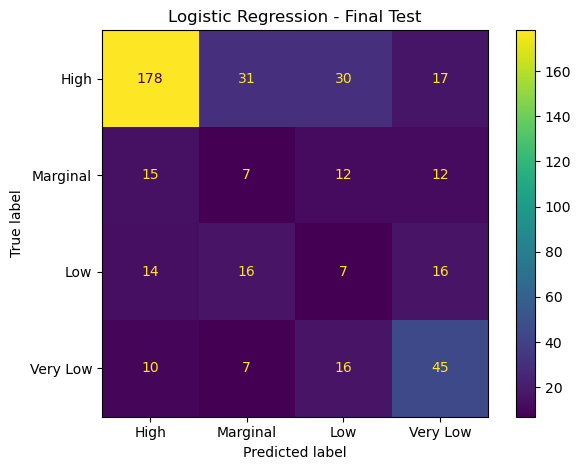

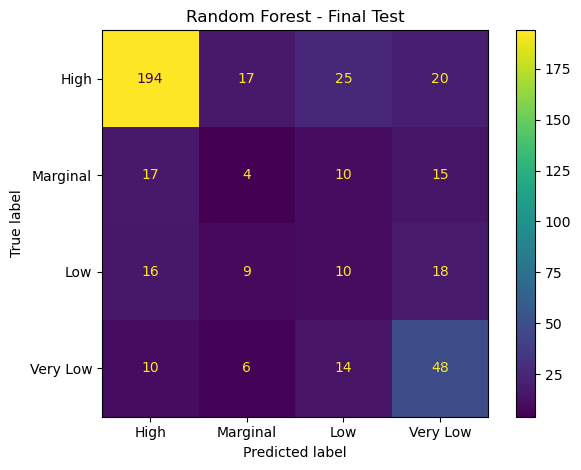

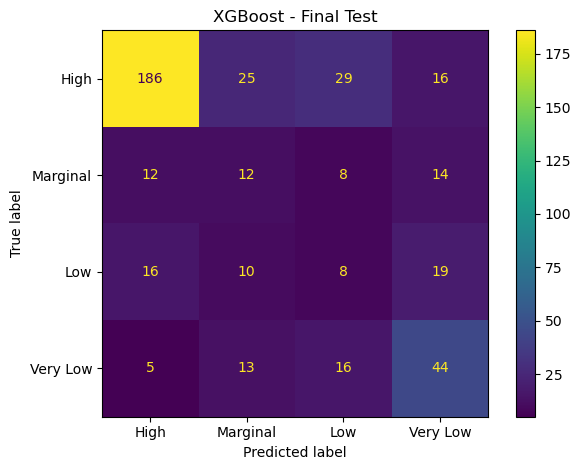

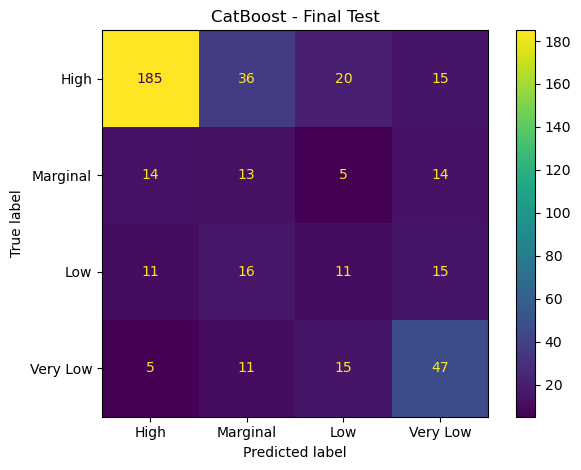

In [13]:
X_test_cat = prepare_catboost_frame(X_test)

test_inputs = {
    "Logistic Regression": (selected_models["Logistic Regression"], X_test),
    "Random Forest": (selected_models["Random Forest"], X_test),
    "XGBoost": (selected_models["XGBoost"], X_test),
    "CatBoost": (selected_models["CatBoost"], X_test_cat)
}

(
    final_test_results,
    final_test_per_class,
    final_test_ordinal,
    final_test_predictions,
    final_test_probabilities
) = evaluate_model_collection(test_inputs, y_test)

final_test_recall = final_test_per_class.pivot(
    index="Model", columns="Class", values="Recall"
)

display(final_test_results.round(4))
display(final_test_per_class.round(4))
display(final_test_recall.round(4))
display(final_test_ordinal.round(4))

final_test_results.to_csv(TEST_DIR / "final_test_metrics.csv")
final_test_per_class.to_csv(TEST_DIR / "final_test_per_class_metrics.csv", index=False)
final_test_recall.to_csv(TEST_DIR / "final_test_class_recall.csv")
final_test_ordinal.to_csv(TEST_DIR / "final_test_ordinal_error_analysis.csv")

save_confusion_matrices(
    final_test_predictions, y_test, FIGURE_DIR / "test", "Final Test"
)


## 14. SHAP explainability

SHAP is run after model selection. Interpret SHAP values as predictive associations, not causal effects.

To keep runtime manageable, the code samples test observations. For multiclass models, inspect class-specific explanations as well as aggregate absolute SHAP magnitude.


In [14]:
#%pip install shap

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


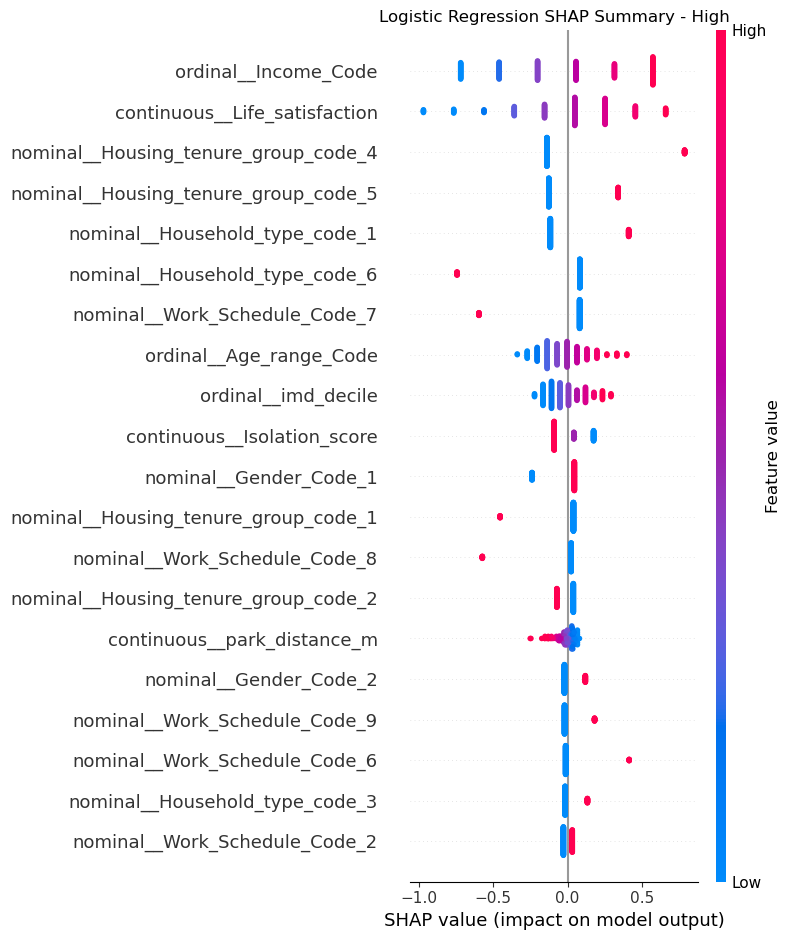

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


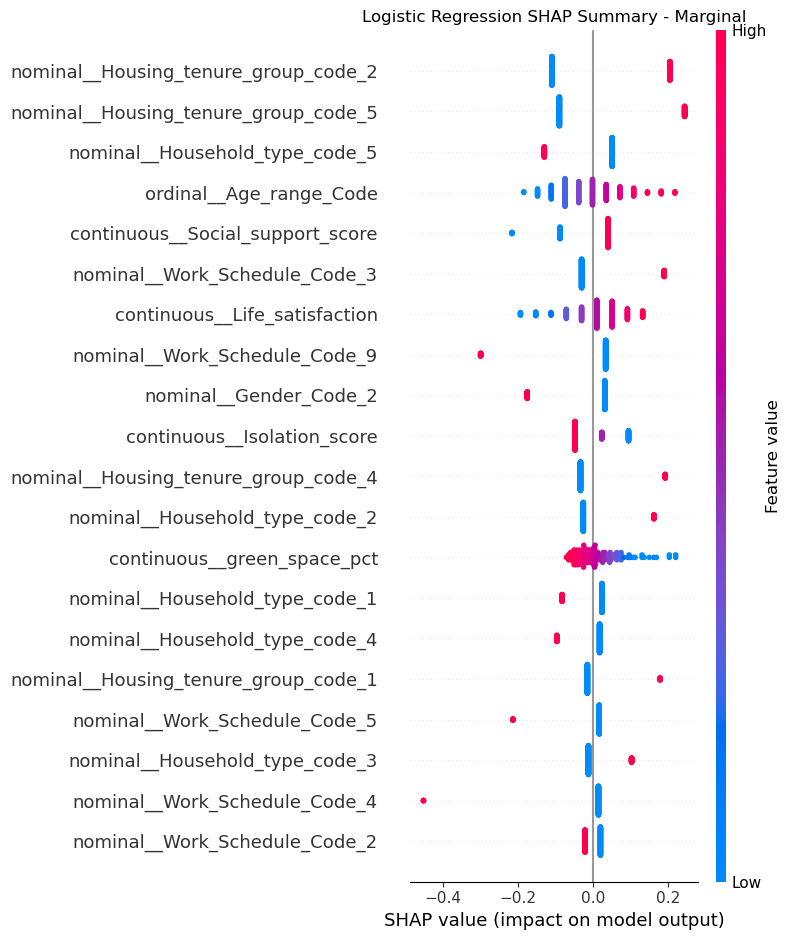

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


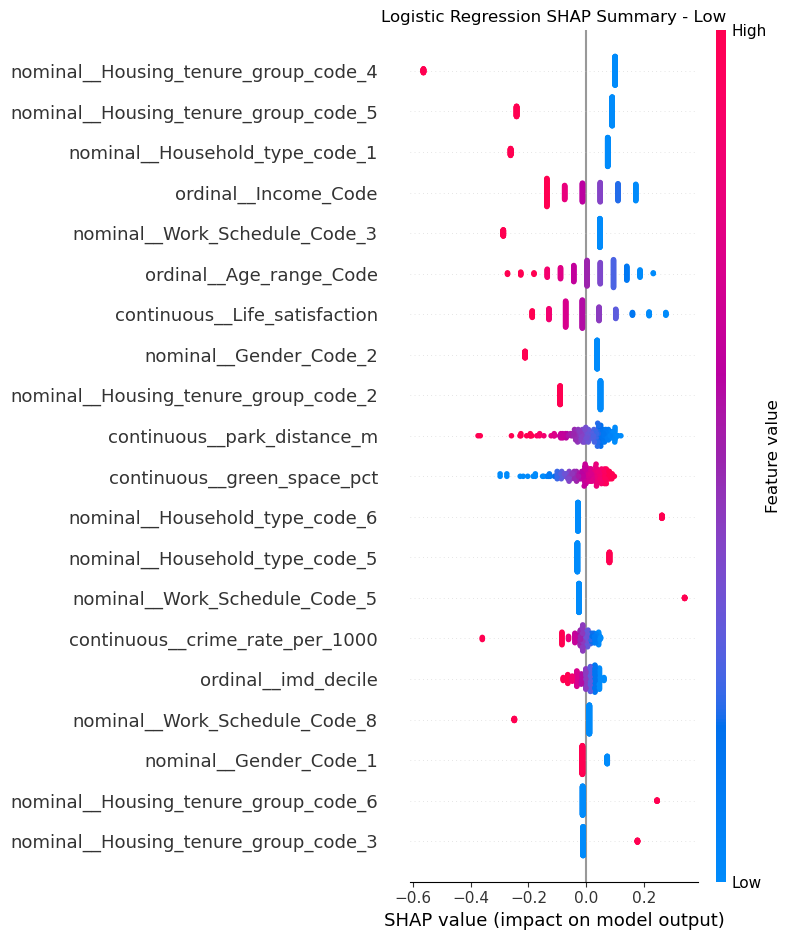

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


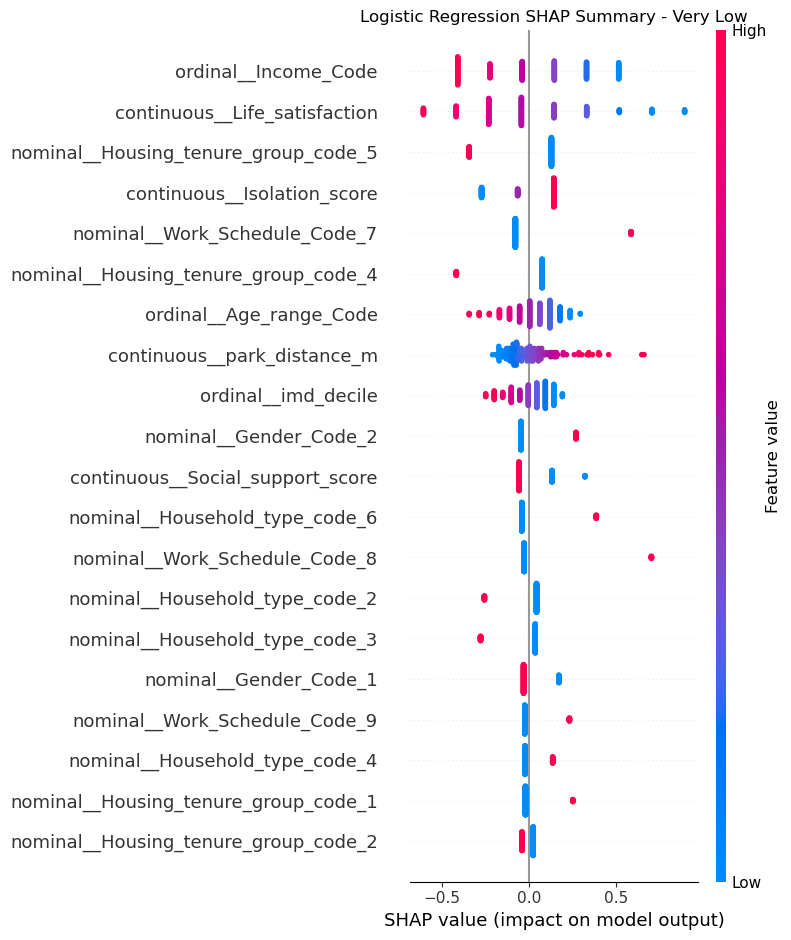

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


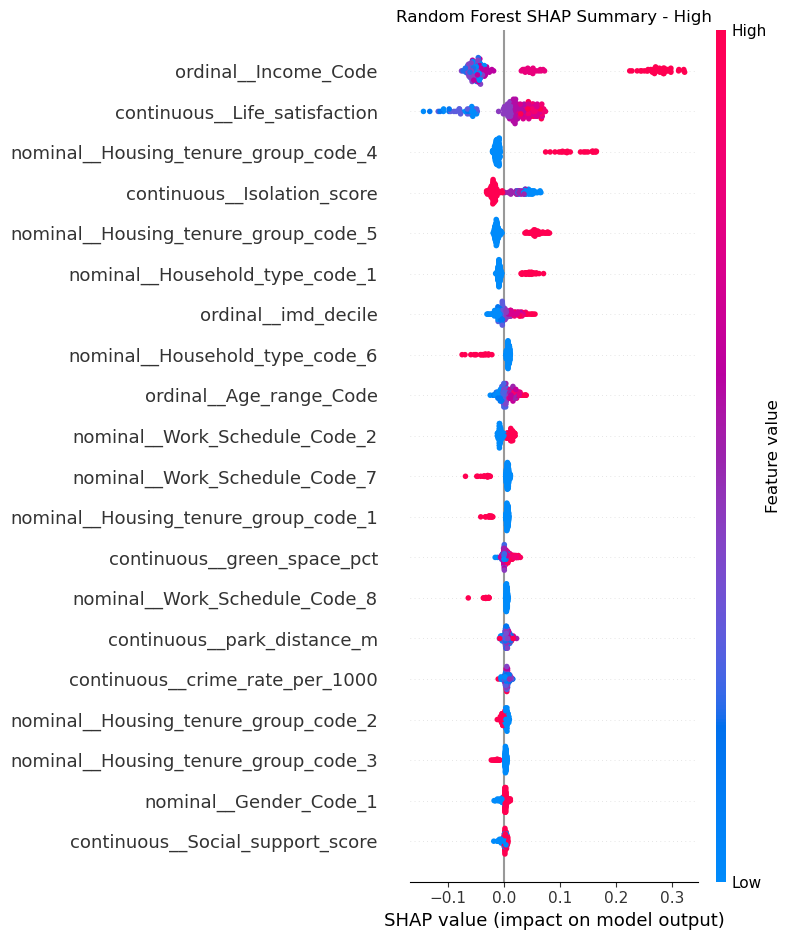

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


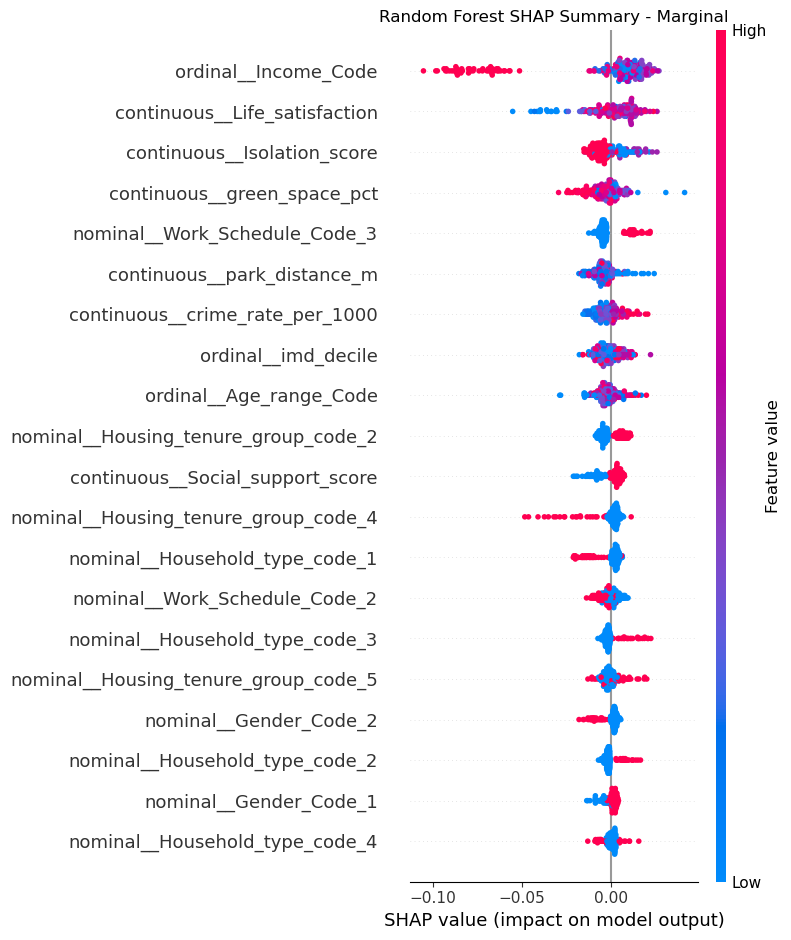

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


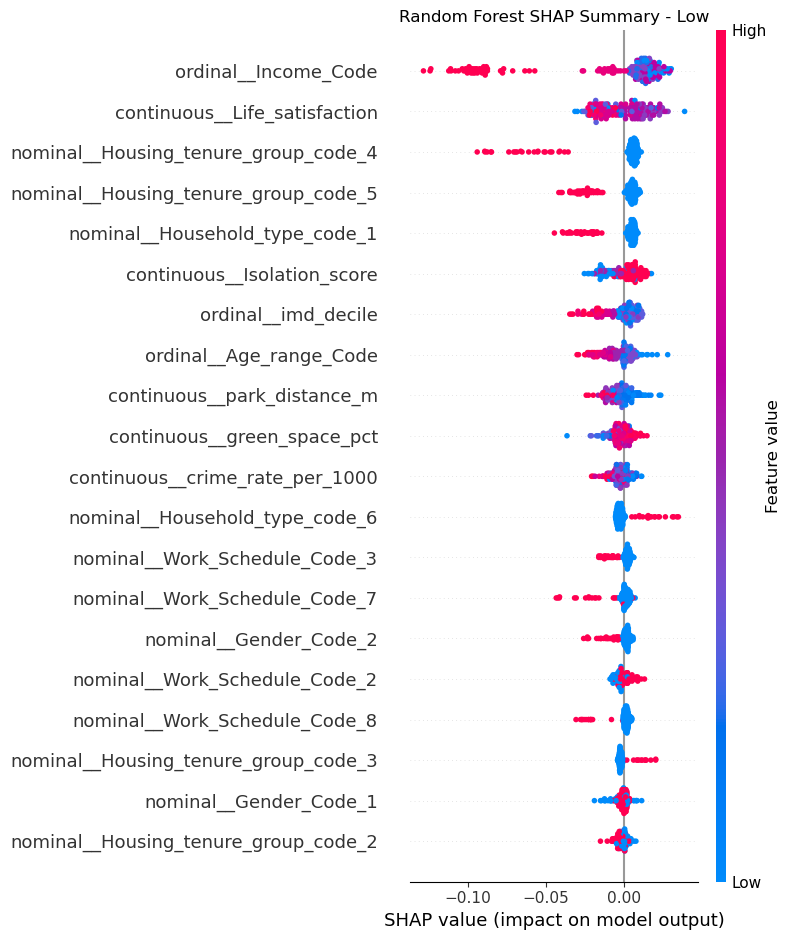

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


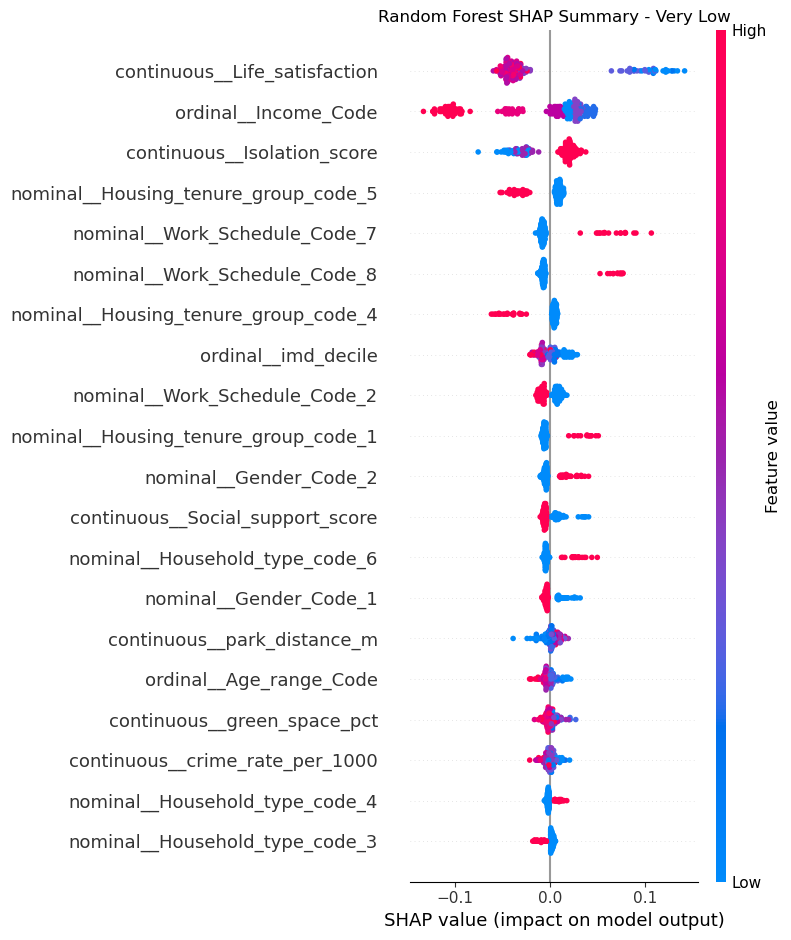

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


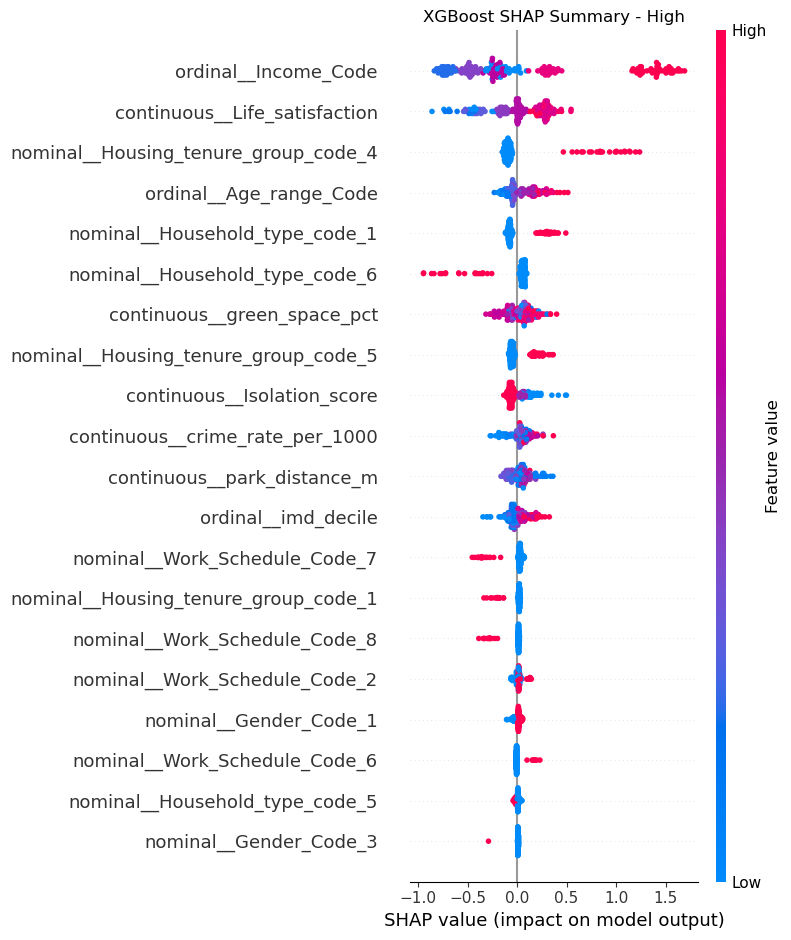

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


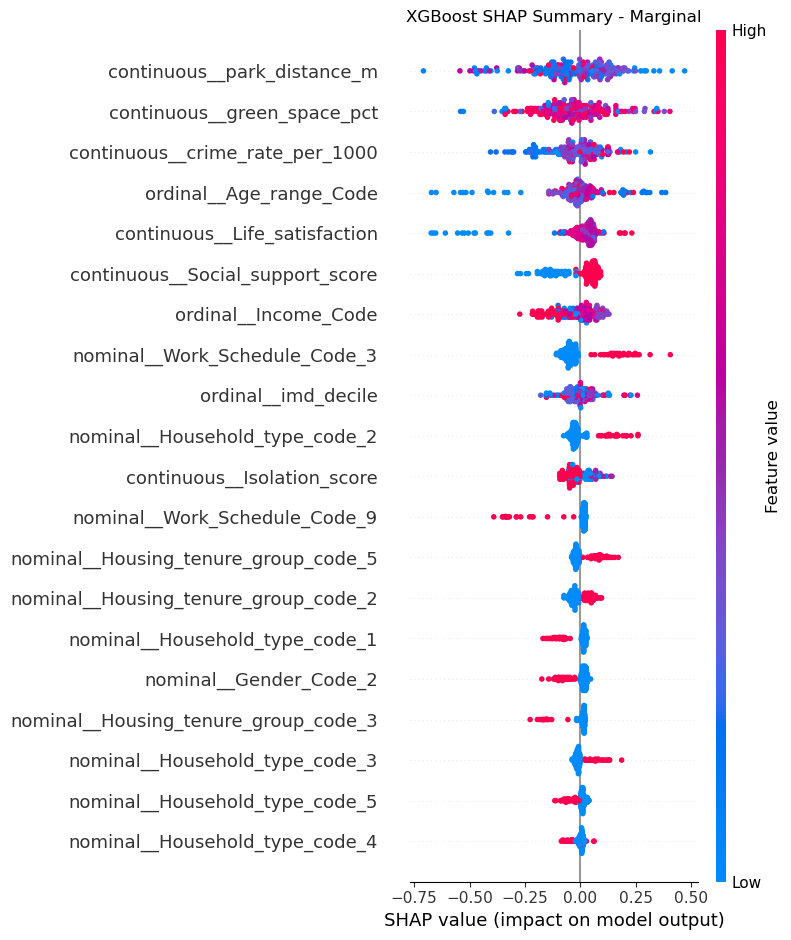

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


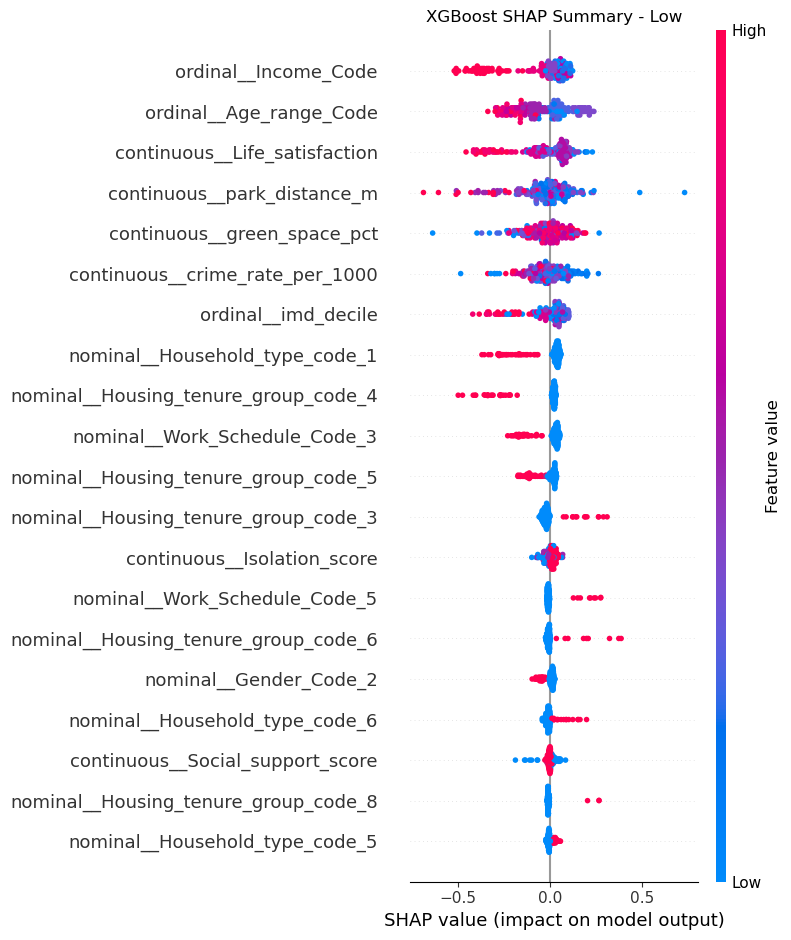

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/479626542.py:56: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


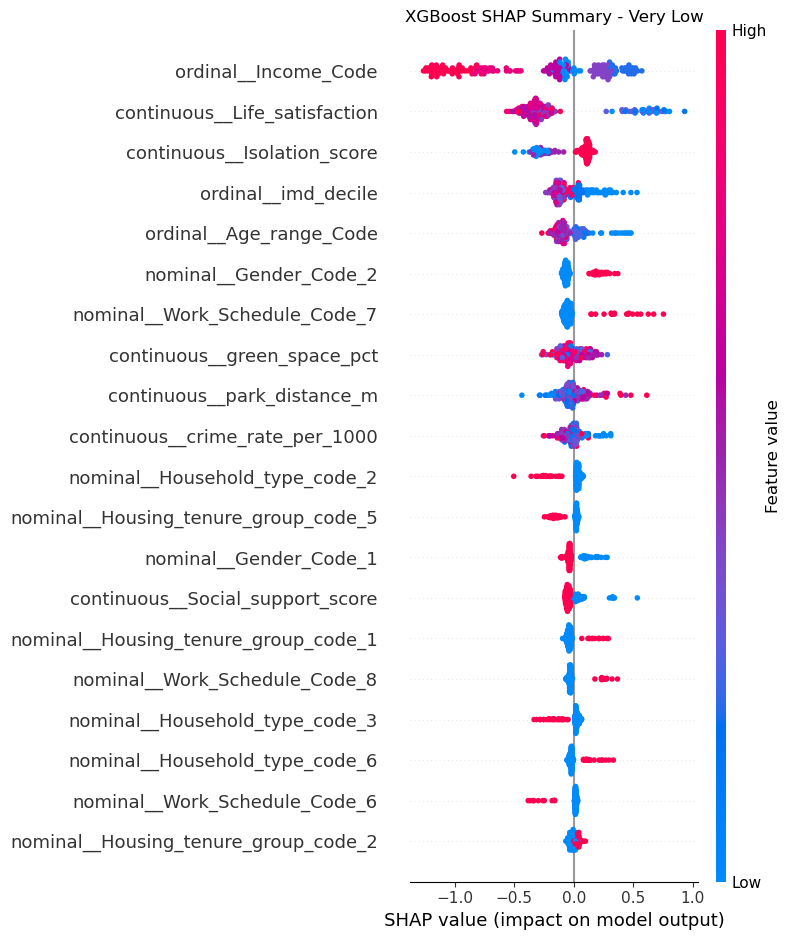

In [15]:
# Install SHAP in the environment first if required:
#%pip install shap

import shap

SHAP_SAMPLE_SIZE = min(200, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
X_shap_cat = prepare_catboost_frame(X_shap)

shap_output_dir = FIGURE_DIR / "shap"
shap_output_dir.mkdir(parents=True, exist_ok=True)

def get_transformed_feature_names(pipeline):
    return pipeline.named_steps["preprocessor"].get_feature_names_out()

def run_pipeline_shap(model_name, pipeline, X_sample, model_kind):
    preprocessor = pipeline.named_steps["preprocessor"]
    estimator = pipeline.named_steps["classifier"]
    X_transformed = preprocessor.transform(X_sample)
    feature_names = get_transformed_feature_names(pipeline)

    if hasattr(X_transformed, "toarray"):
        X_explain = X_transformed.toarray()
    else:
        X_explain = np.asarray(X_transformed)

    if model_kind == "linear":
        explainer = shap.LinearExplainer(estimator, X_explain)
    else:
        explainer = shap.TreeExplainer(estimator)

    shap_values = explainer.shap_values(X_explain)

    # Multiclass SHAP output varies by SHAP version.
    # Plot each class when a list of class-specific arrays is returned.
    if isinstance(shap_values, list):
        for class_idx, values in enumerate(shap_values):
            shap.summary_plot(
                values,
                X_explain,
                feature_names=feature_names,
                show=False
            )
            plt.title(f"{model_name} SHAP Summary - {CLASS_LABELS[class_idx]}")
            plt.tight_layout()
            plt.savefig(
                shap_output_dir / f"{model_name.lower().replace(' ', '_')}_class_{class_idx}_summary.png",
                dpi=300,
                bbox_inches="tight"
            )
            plt.show()
    else:
        values = np.asarray(shap_values)
        if values.ndim == 3:
            for class_idx in range(values.shape[-1]):
                shap.summary_plot(
                    values[:, :, class_idx],
                    X_explain,
                    feature_names=feature_names,
                    show=False
                )
                plt.title(f"{model_name} SHAP Summary - {CLASS_LABELS[class_idx]}")
                plt.tight_layout()
                plt.savefig(
                    shap_output_dir / f"{model_name.lower().replace(' ', '_')}_class_{class_idx}_summary.png",
                    dpi=300,
                    bbox_inches="tight"
                )
                plt.show()
        else:
            shap.summary_plot(
                values,
                X_explain,
                feature_names=feature_names,
                show=False
            )
            plt.title(f"{model_name} SHAP Summary")
            plt.tight_layout()
            plt.savefig(
                shap_output_dir / f"{model_name.lower().replace(' ', '_')}_summary.png",
                dpi=300,
                bbox_inches="tight"
            )
            plt.show()

# Explain the three sklearn-compatible selected models.
run_pipeline_shap(
    "Logistic Regression",
    selected_models["Logistic Regression"],
    X_shap,
    "linear"
)

run_pipeline_shap(
    "Random Forest",
    selected_models["Random Forest"],
    X_shap,
    "tree"
)

run_pipeline_shap(
    "XGBoost",
    selected_models["XGBoost"],
    X_shap,
    "tree"
)


CatBoost SHAP array shape: (200, 4, 14)


/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/3468286101.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


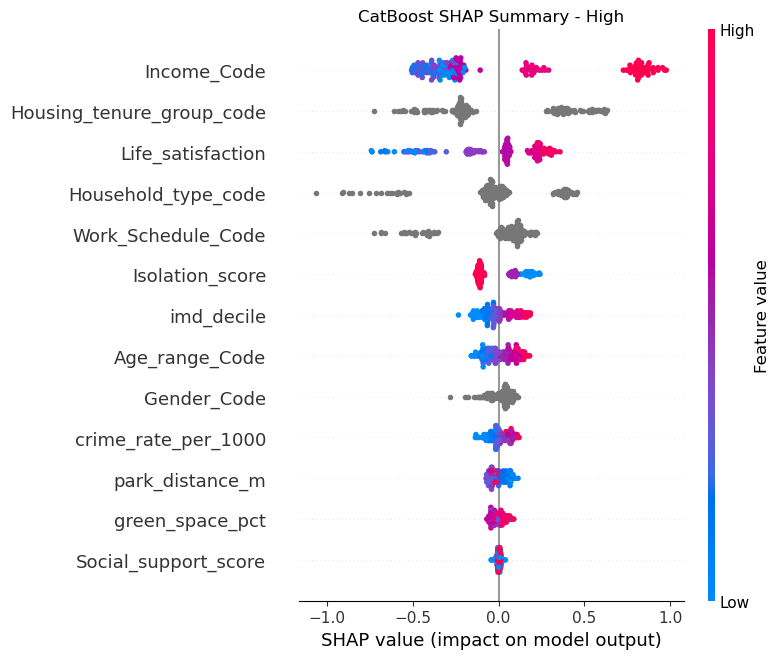

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/3468286101.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


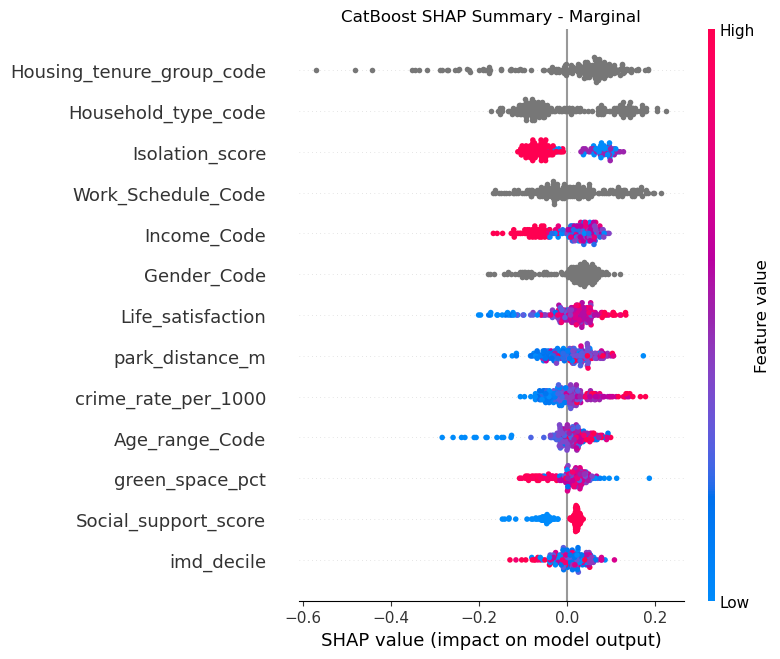

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/3468286101.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


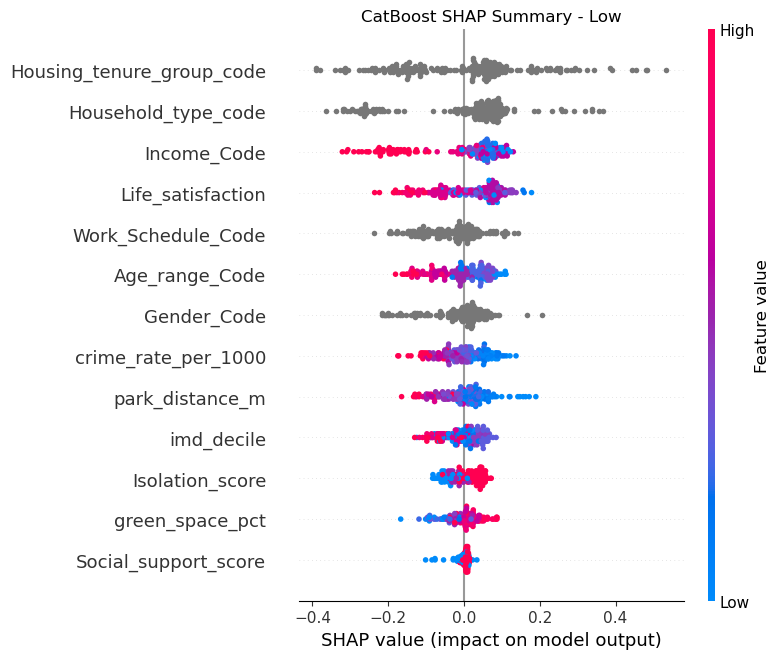

/var/folders/s7/tc32003s3vx1b6dyk4yxjqg00000gn/T/ipykernel_88775/3468286101.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


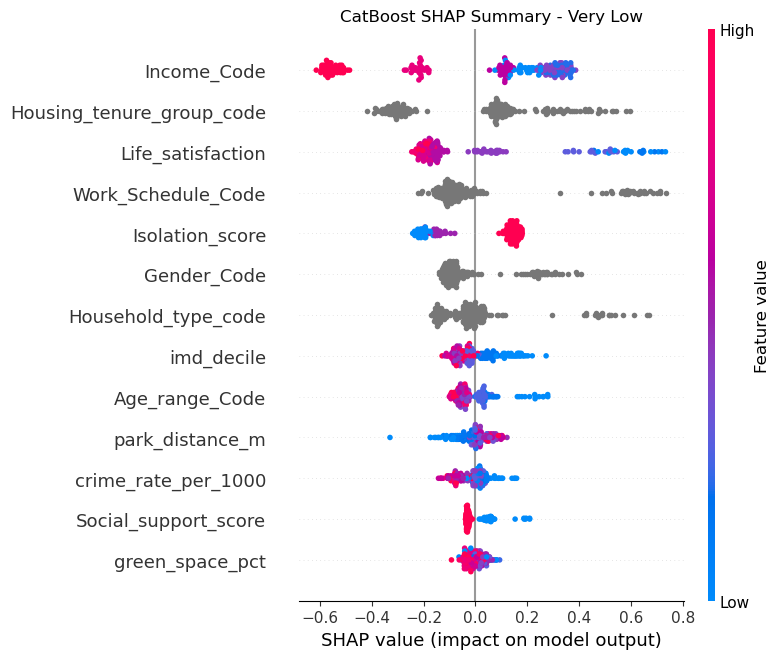

In [16]:
# CatBoost SHAP: use CatBoost's native SHAP calculation for reliable categorical handling.
from catboost import Pool

cat_model = selected_models["CatBoost"]
cat_pool = Pool(
    X_shap_cat,
    cat_features=nominal_features
)

cat_shap = cat_model.get_feature_importance(
    cat_pool,
    type="ShapValues"
)

# For multiclass CatBoost, output is commonly:
# (n_samples, n_classes, n_features + 1)
cat_shap = np.asarray(cat_shap)

print("CatBoost SHAP array shape:", cat_shap.shape)

if cat_shap.ndim == 3:
    for class_idx in range(cat_shap.shape[1]):
        values = cat_shap[:, class_idx, :-1]
        shap.summary_plot(
            values,
            X_shap_cat,
            feature_names=X_shap_cat.columns.tolist(),
            show=False
        )
        plt.title(f"CatBoost SHAP Summary - {CLASS_LABELS[class_idx]}")
        plt.tight_layout()
        plt.savefig(
            shap_output_dir / f"catboost_class_{class_idx}_summary.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()
else:
    print(
        "CatBoost returned an unexpected SHAP shape. "
        "Inspect cat_shap.shape before plotting rather than forcing an interpretation."
    )


## 15. Save deployable model artifacts and metadata


In [17]:
import joblib
import sklearn
import xgboost
import catboost

# Save sklearn-compatible pipelines.
joblib.dump(
    selected_models["Logistic Regression"],
    MODEL_DIR / "logistic_regression.joblib"
)
joblib.dump(
    selected_models["Random Forest"],
    MODEL_DIR / "random_forest.joblib"
)
joblib.dump(
    selected_models["XGBoost"],
    MODEL_DIR / "xgboost.joblib"
)

# Save CatBoost natively.
selected_models["CatBoost"].save_model(
    str(MODEL_DIR / "catboost.cbm")
)

metadata = {
    "project": "Drivers of Food Insecurity in London, United Kingdom",
    "target": "food_security_score",
    "target_type": "ordinal_multiclass_classification",
    "class_mapping": {str(k): v for k, v in CLASS_LABELS.items()},
    "raw_score_mapping": {
        "0-1": "High",
        "2-3": "Marginal",
        "4-6": "Low",
        "7-9": "Very Low"
    },
    "random_state": RANDOM_STATE,
    "split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15,
        "stratified": True
    },
    "features": X_train.columns.tolist(),
    "feature_order": X_train.columns.tolist(),
    "nominal_features": nominal_features,
    "ordinal_features": ordinal_features,
    "continuous_features": continuous_features,
    "excluded_columns": DROP_COLUMNS,
    "selected_variants": selected_variant,
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "catboost": catboost.__version__
    }
}

with (MODEL_DIR / "metadata.json").open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts to:", MODEL_DIR.resolve())


Saved artifacts to: /Users/olabanjibadejo/Documents/vanguard-group/models/food_security


## 16. Reproducibility summary


In [18]:
print("Random seed:", RANDOM_STATE)
print("Training observations:", len(X_train))
print("Validation observations:", len(X_val))
print("Test observations:", len(X_test))
print("Predictor count:", X_train.shape[1])
print("Selected variants:", selected_variant)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_ROOT)


Random seed: 42
Training observations: 2020
Validation observations: 433
Test observations: 433
Predictor count: 13
Selected variants: {'Logistic Regression': 'improved', 'Random Forest': 'improved', 'XGBoost': 'improved', 'CatBoost': 'improved'}
Model directory: ../models/food_security
Output directory: ../outputs/Training/food_insecurity
